In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1

In [2]:
df = pd.read_csv('gym.csv')

df.head()

,age,gender,weight,height,max_bpm,avg_bpm,resting_bpm,session_duration,calories_burned,workout_type,fat_percentage,water_intake,workout_frequency,experience_level,bmi
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
df.describe()

,age,weight,height,max_bpm,avg_bpm,resting_bpm,session_duration,calories_burned,fat_percentage,water_intake,workout_frequency,experience_level,bmi
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


The dataset features are already in order

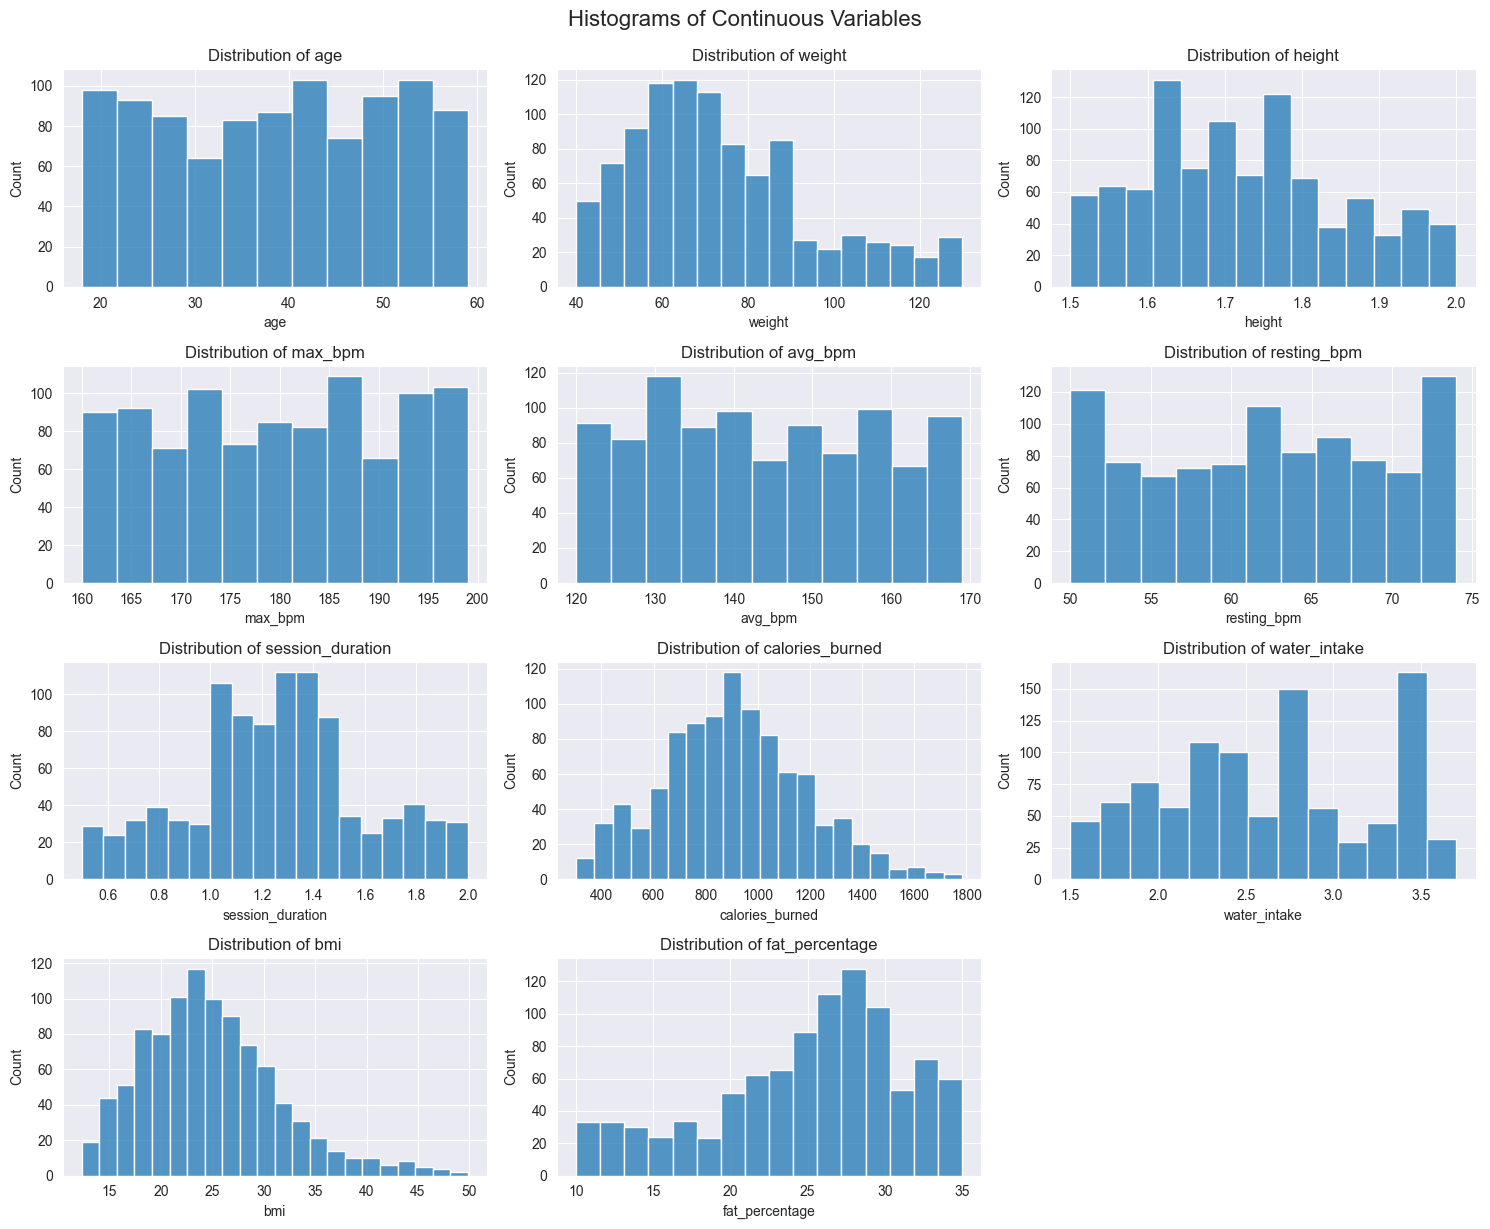

In [6]:
continuous_vars = ['age', 'weight', 'height', 'max_bpm',
                   'avg_bpm', 'resting_bpm', 'session_duration', 'calories_burned',
                   'water_intake', 'bmi', 'fat_percentage']

plt.figure(figsize=(15, 12))

for i, var in enumerate(continuous_vars, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[var])
    plt.title(f'Distribution of {var}')
    plt.tight_layout()
plt.suptitle('Histograms of Continuous Variables', y=1.02, fontsize=16)
plt.show()

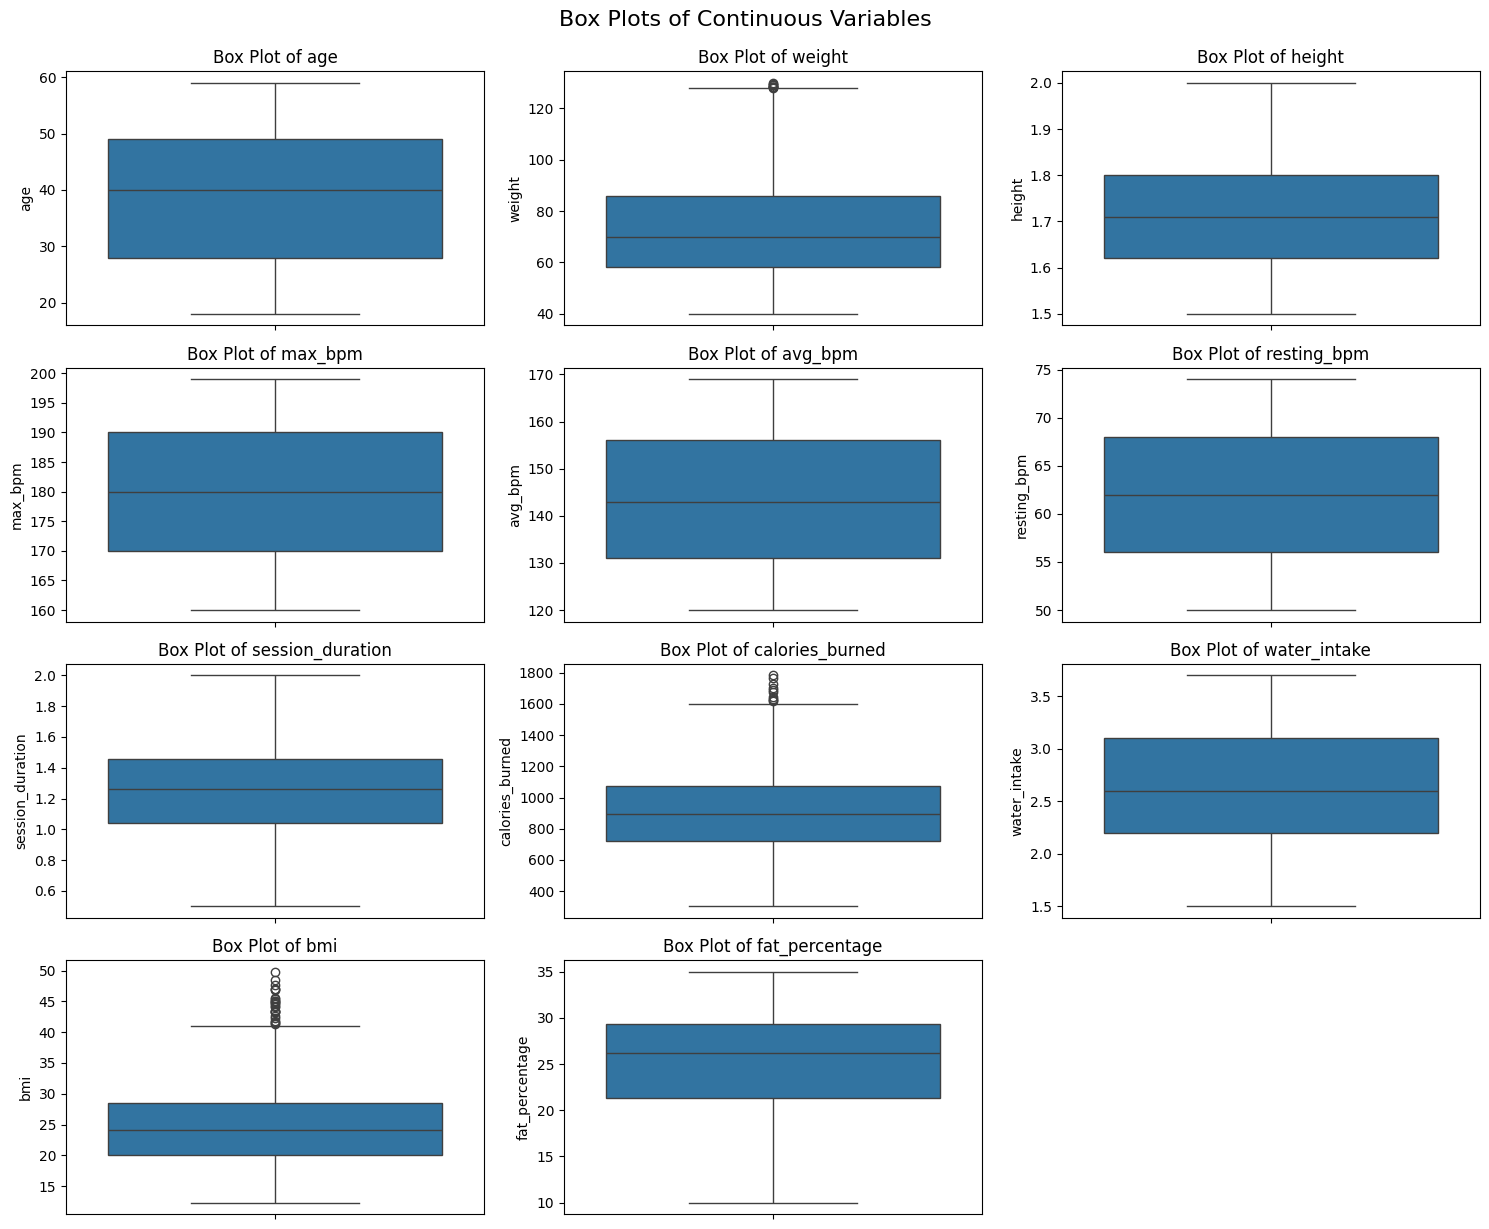

In [13]:
plt.figure(figsize=(15, 12))
for i, var in enumerate(continuous_vars, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[var])
    plt.title(f'Box Plot of {var}')
    plt.tight_layout()
plt.suptitle('Box Plots of Continuous Variables', y=1.02, fontsize=16)
plt.show()

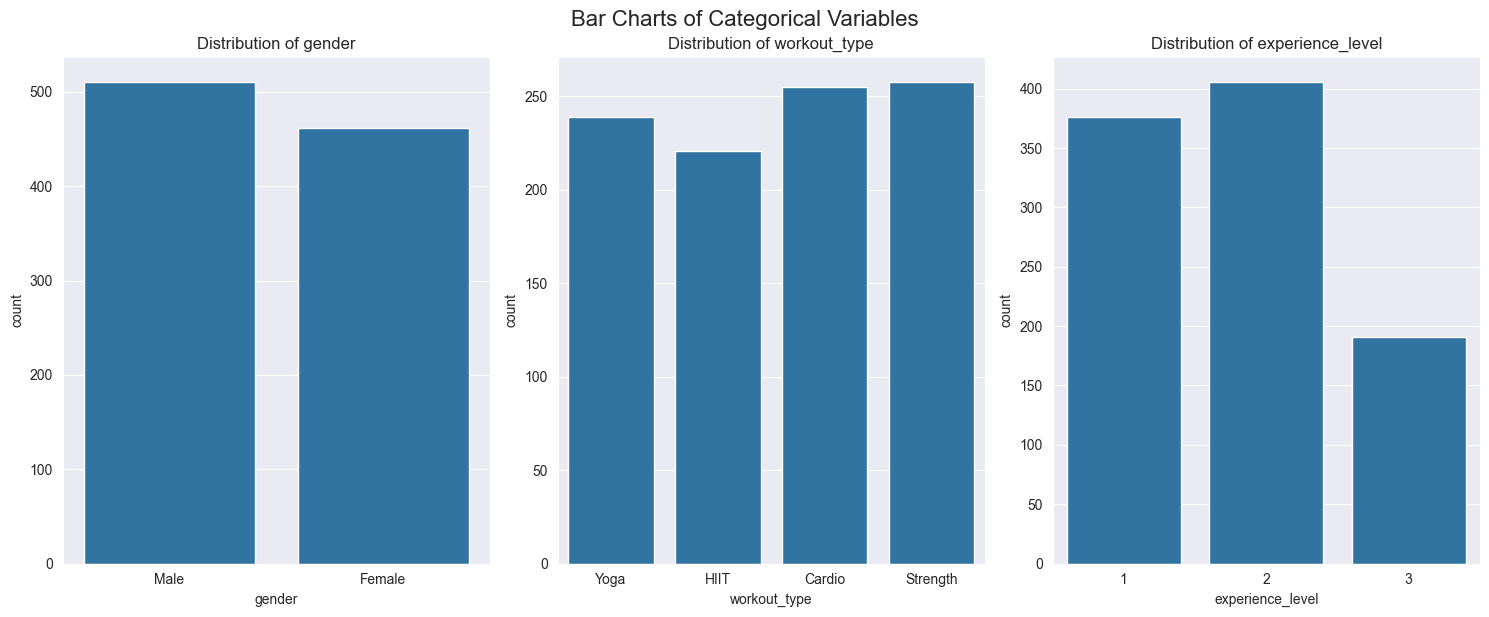

In [7]:
categorical_vars = ['gender', 'workout_type', 'experience_level']

plt.figure(figsize=(15, 6))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=df[var])
    plt.title(f'Distribution of {var}')
    plt.tight_layout()
plt.suptitle('Bar Charts of Categorical Variables', y=1.02, fontsize=16)
plt.show()

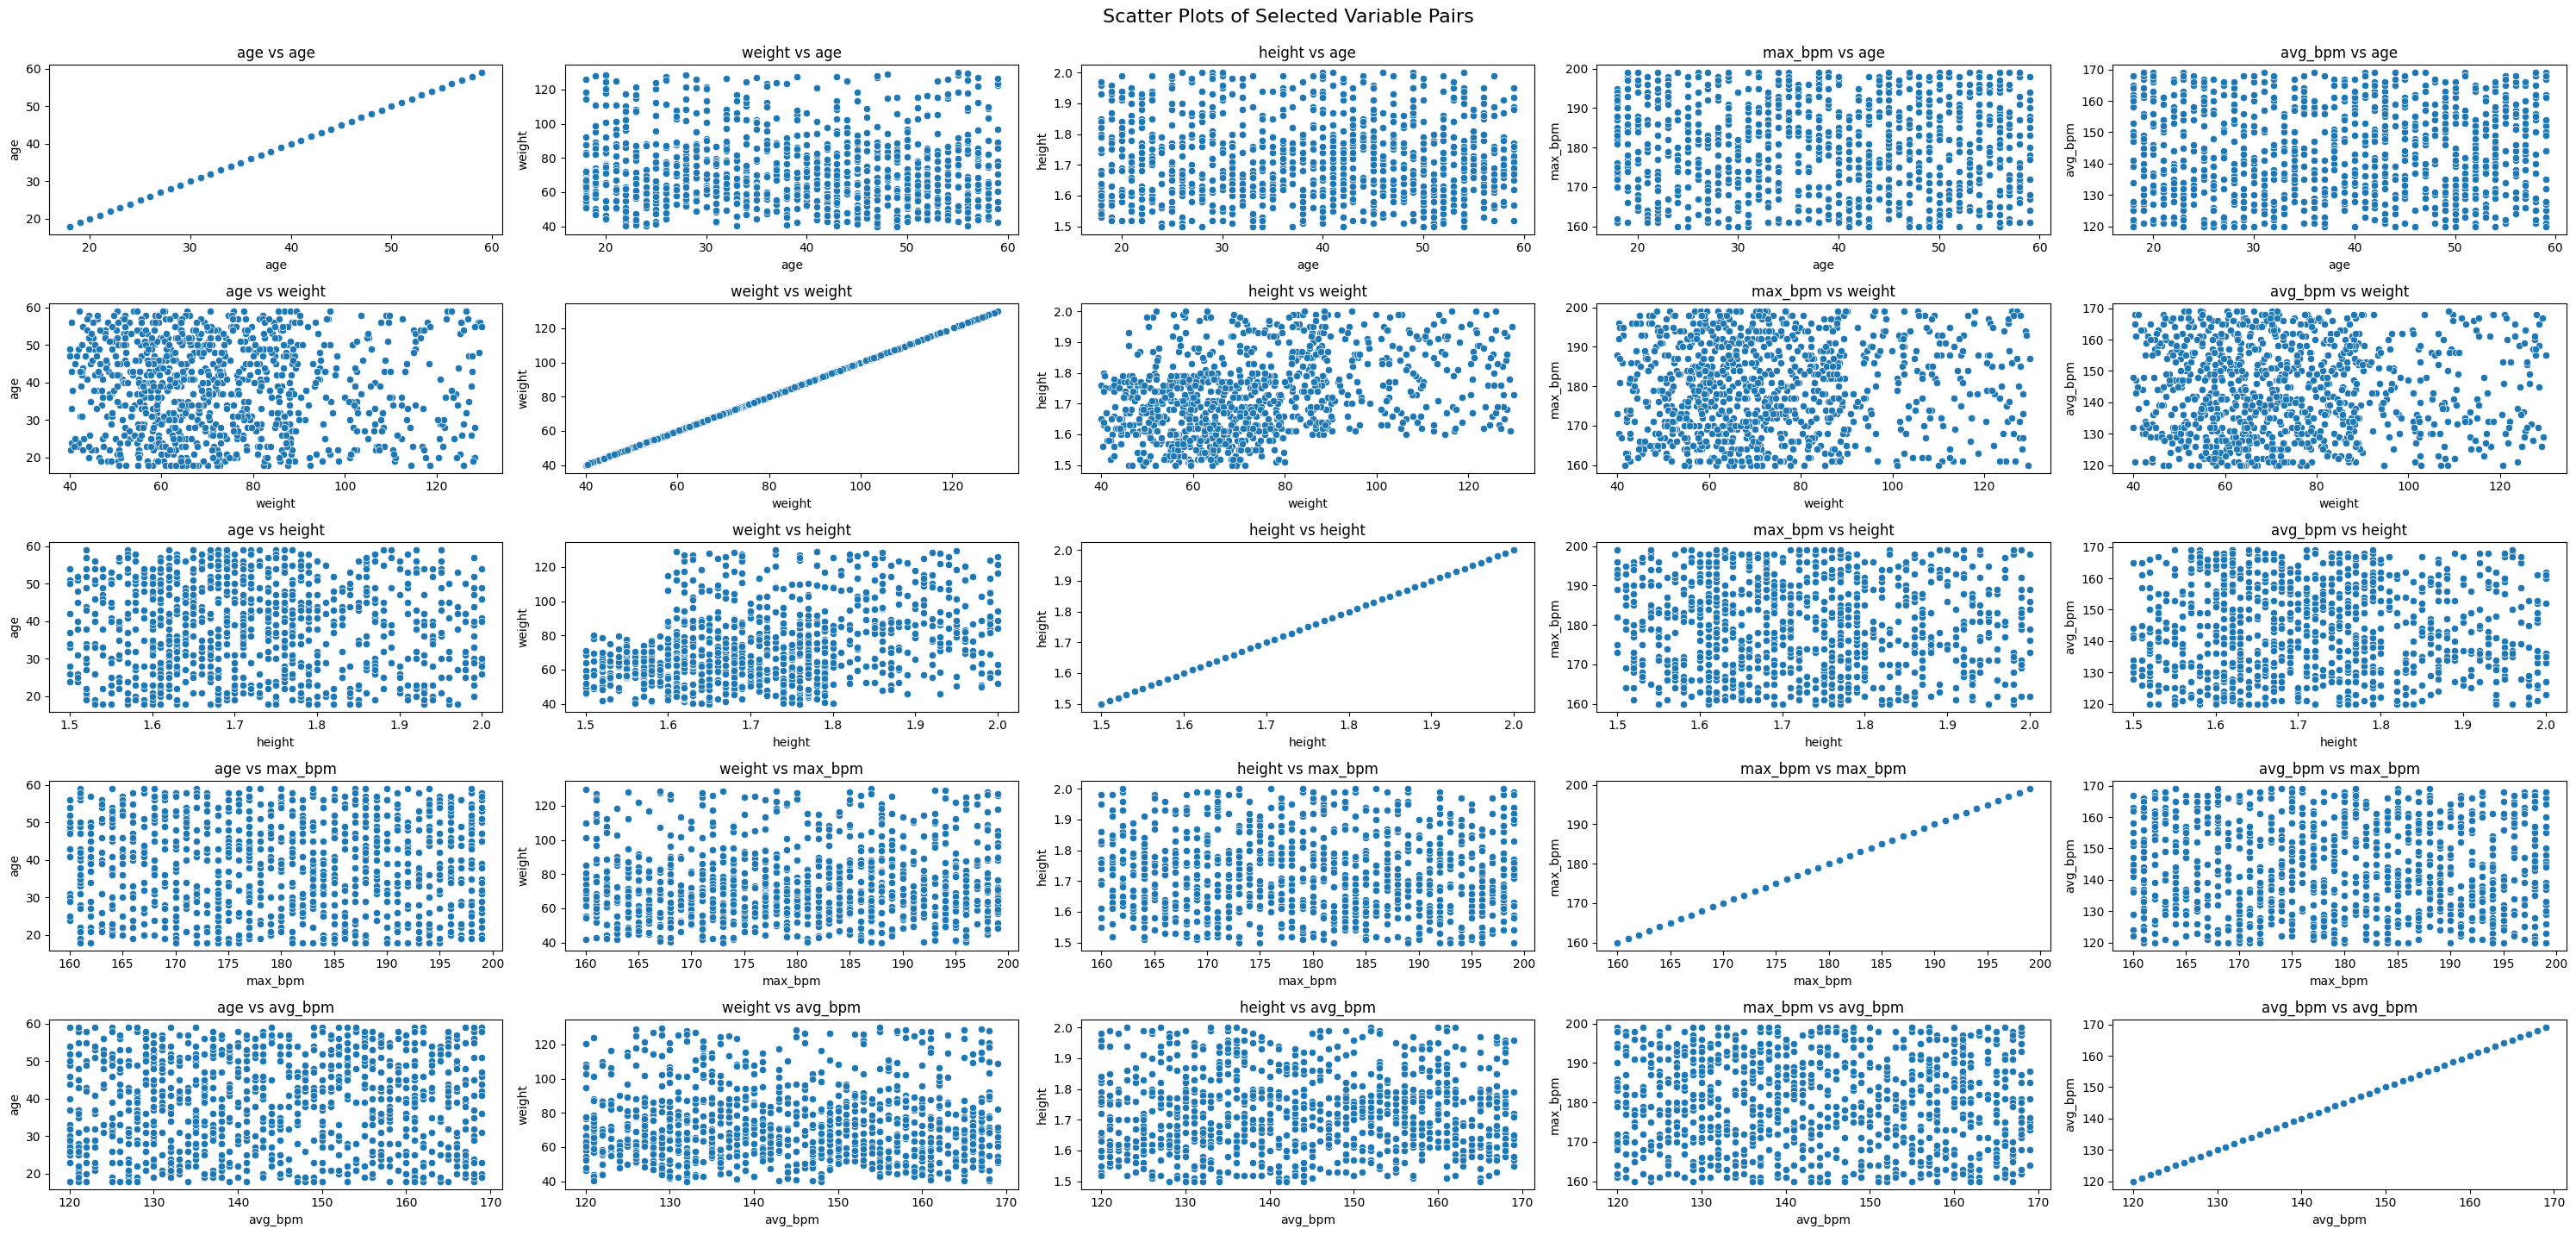

In [24]:
import itertools

features = continuous_vars[:-6]

plt.figure(figsize=(30, 14))

for i, (x, y) in enumerate(itertools.product(features, features), 1):
    plt.subplot(len(features), len(features), i)
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f'{y} vs {x}')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
plt.suptitle('Scatter Plots of Selected Variable Pairs', y=1.02, fontsize=16)
plt.show()

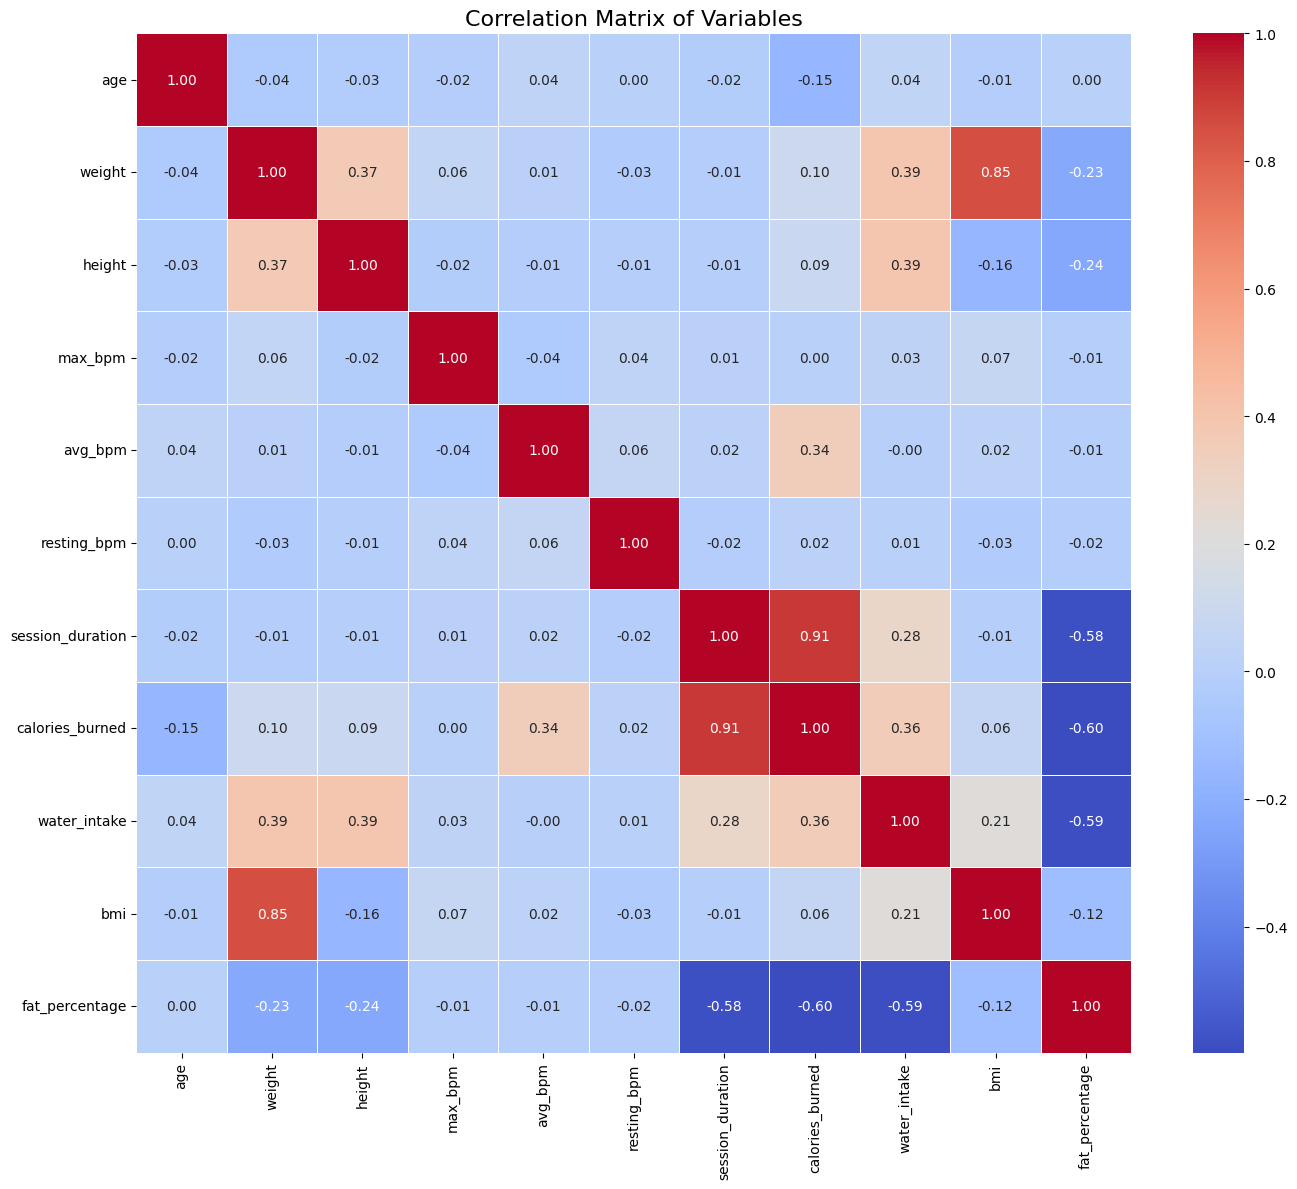

In [17]:
corr_matrix = df[continuous_vars].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Variables', fontsize=16)
plt.tight_layout()
plt.show()

### Task 2

In [3]:
df.isnull().sum()

age                  0
gender               0
weight               0
height               0
max_bpm              0
avg_bpm              0
resting_bpm          0
session_duration     0
calories_burned      0
workout_type         0
fat_percentage       0
water_intake         0
workout_frequency    0
experience_level     0
bmi                  0
dtype: int64

In [8]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound



Outliers in age:
Count: 0 (0.00%)
Lower bound: -3.5, Upper bound: 80.5


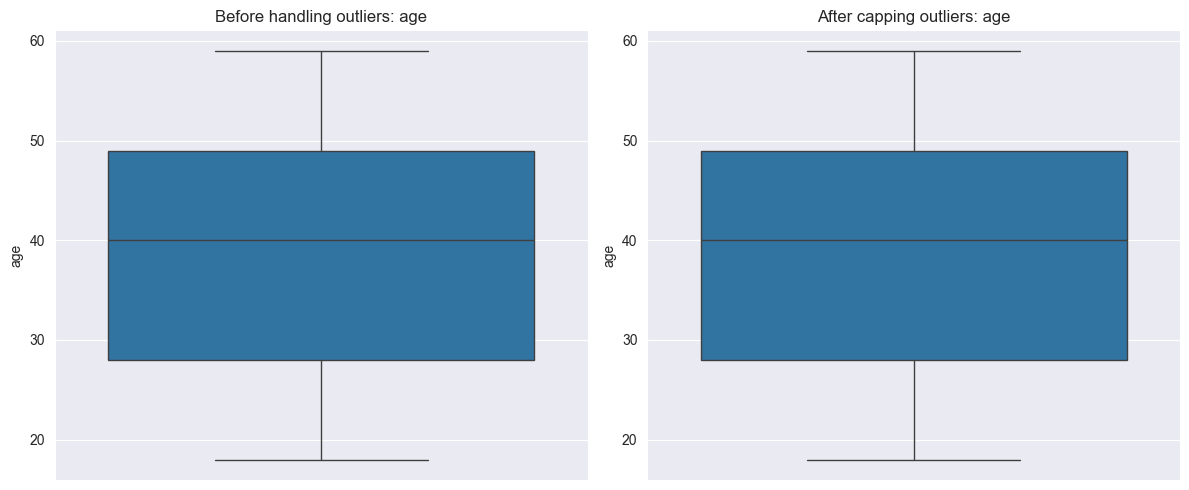


Outliers in weight:
Count: 9 (0.92%)
Lower bound: 16.250000000000007, Upper bound: 127.85


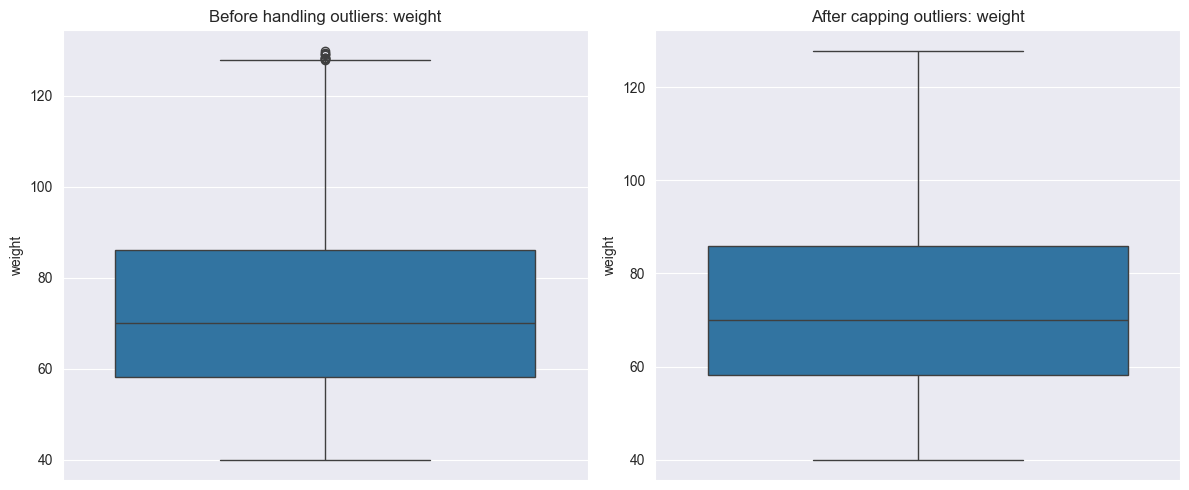


Outliers in height:
Count: 0 (0.00%)
Lower bound: 1.35, Upper bound: 2.07


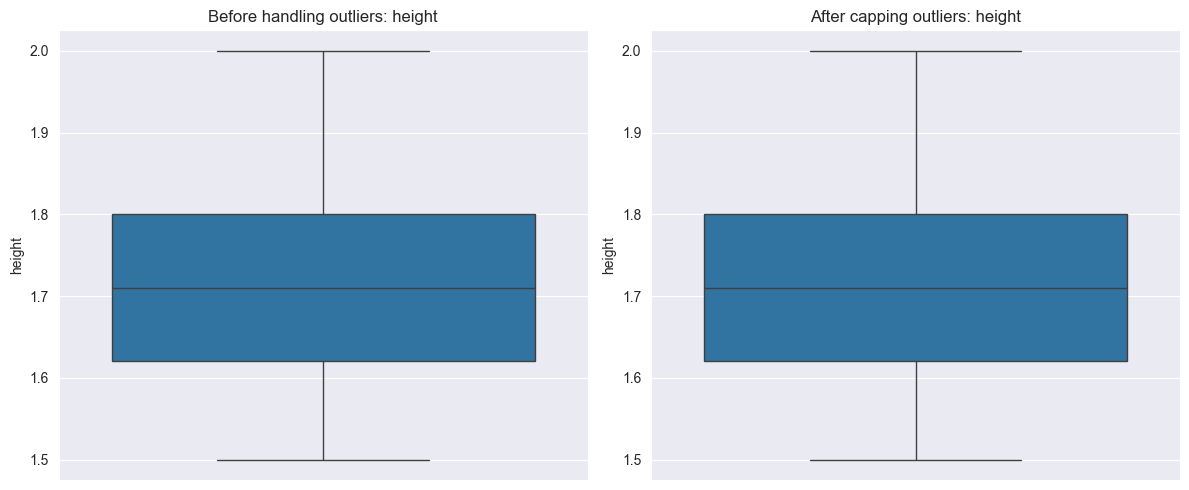


Outliers in max_bpm:
Count: 0 (0.00%)
Lower bound: 140.0, Upper bound: 220.0


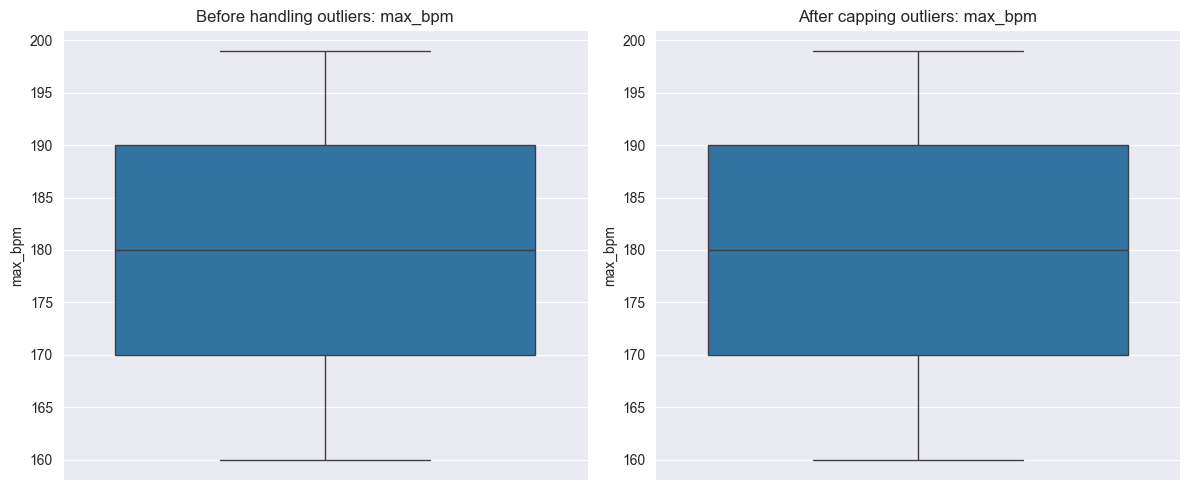


Outliers in avg_bpm:
Count: 0 (0.00%)
Lower bound: 93.5, Upper bound: 193.5


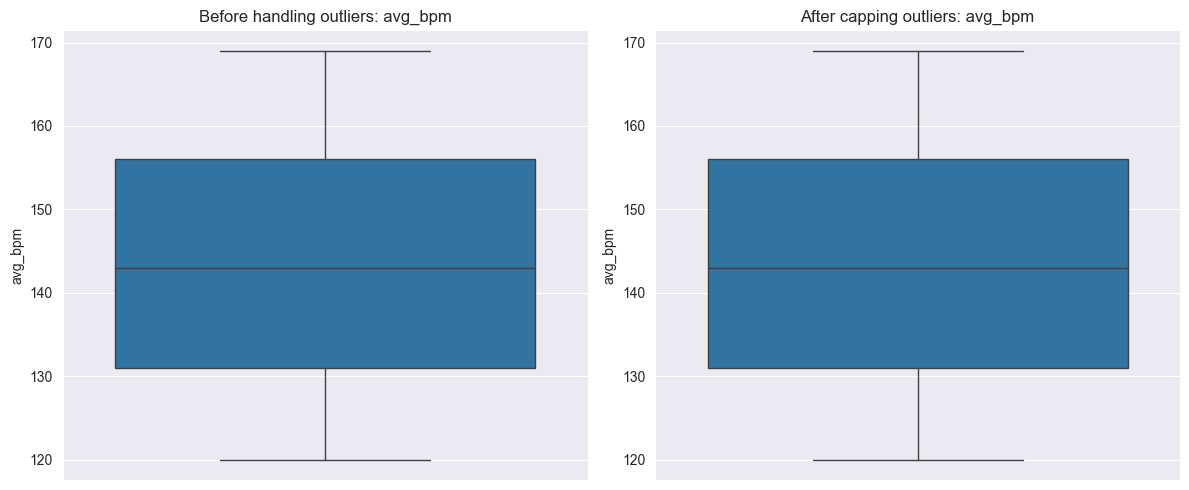


Outliers in resting_bpm:
Count: 0 (0.00%)
Lower bound: 38.0, Upper bound: 86.0


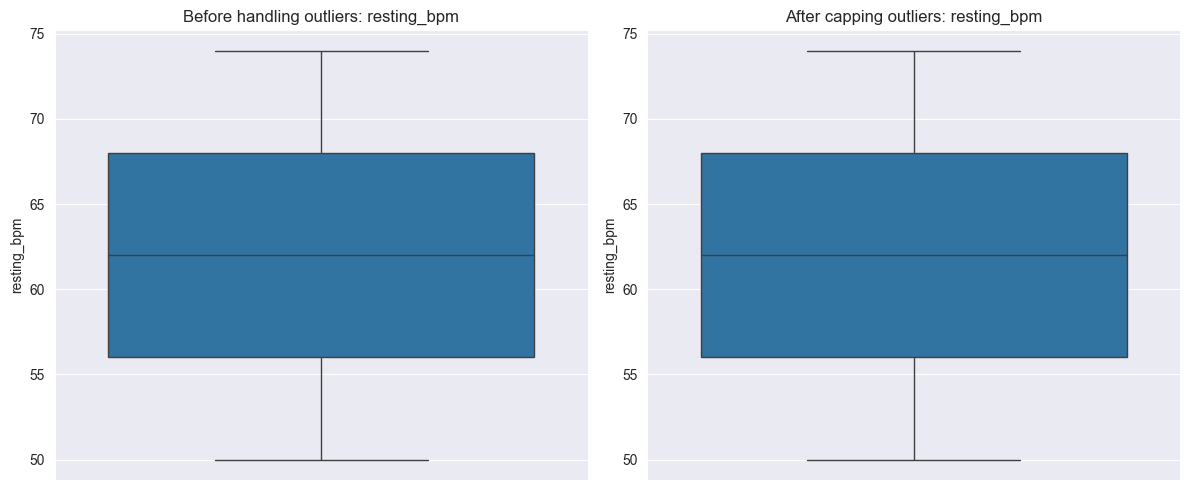


Outliers in session_duration:
Count: 0 (0.00%)
Lower bound: 0.41000000000000014, Upper bound: 2.09


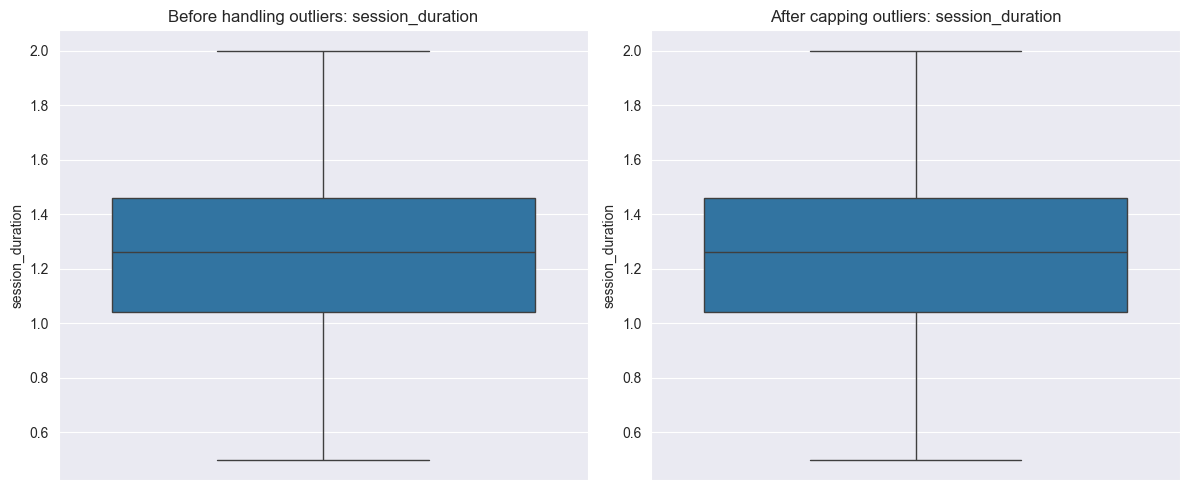


Outliers in calories_burned:
Count: 10 (1.03%)
Lower bound: 186.0, Upper bound: 1610.0


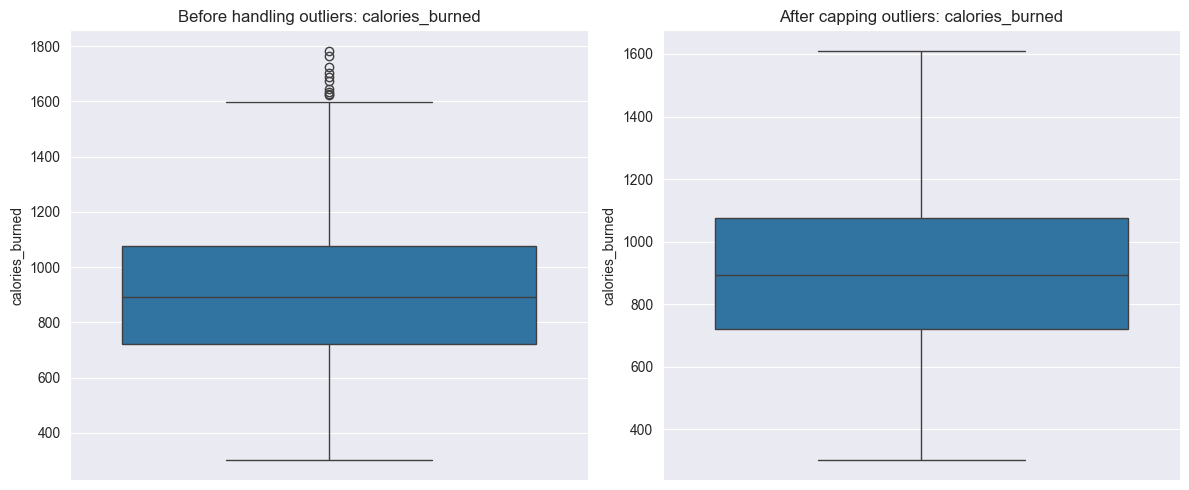


Outliers in water_intake:
Count: 0 (0.00%)
Lower bound: 0.8500000000000003, Upper bound: 4.45


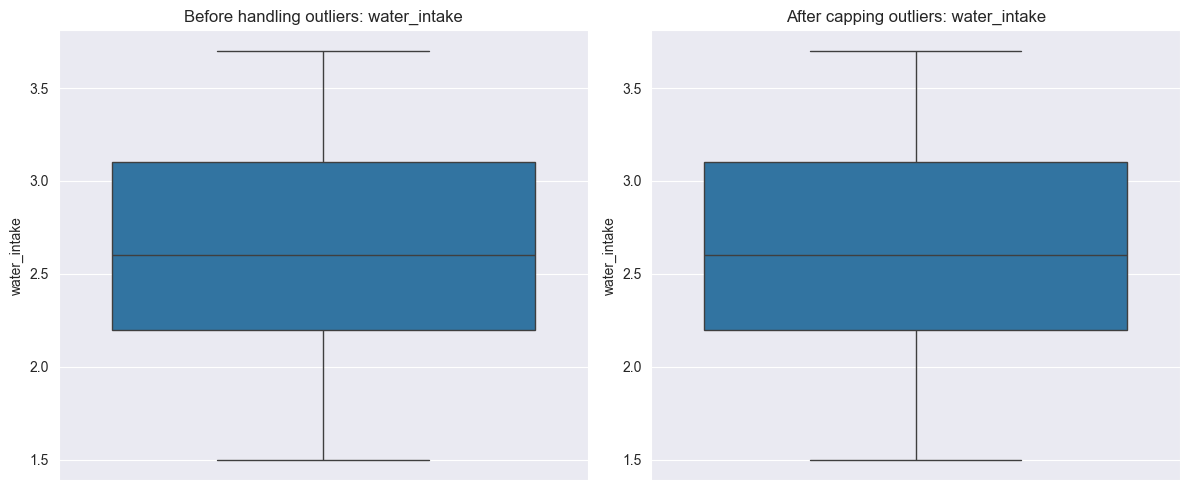


Outliers in bmi:
Count: 25 (2.57%)
Lower bound: 7.4350000000000005, Upper bound: 41.235


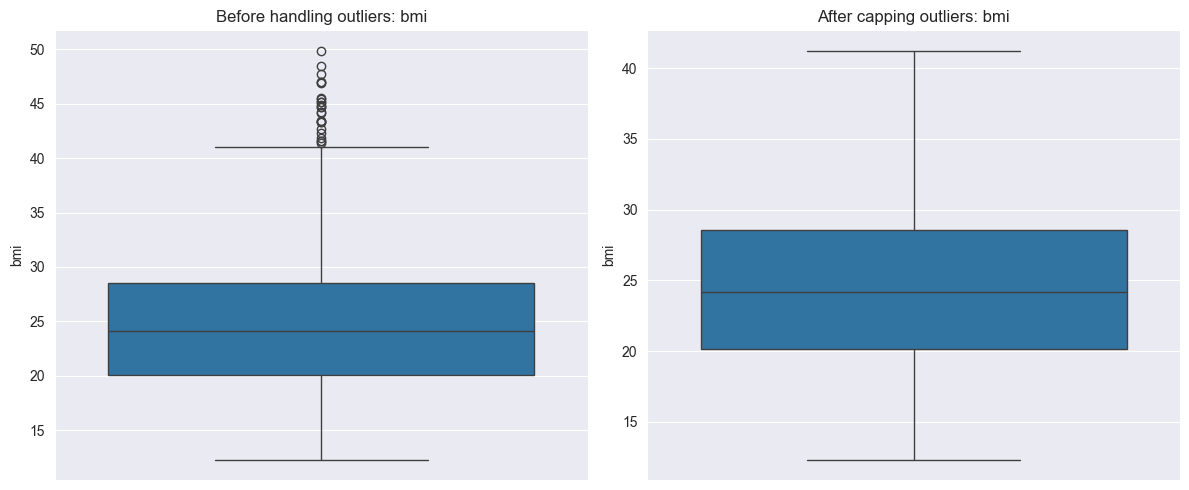


Outliers in fat_percentage:
Count: 0 (0.00%)
Lower bound: 9.3, Upper bound: 41.3


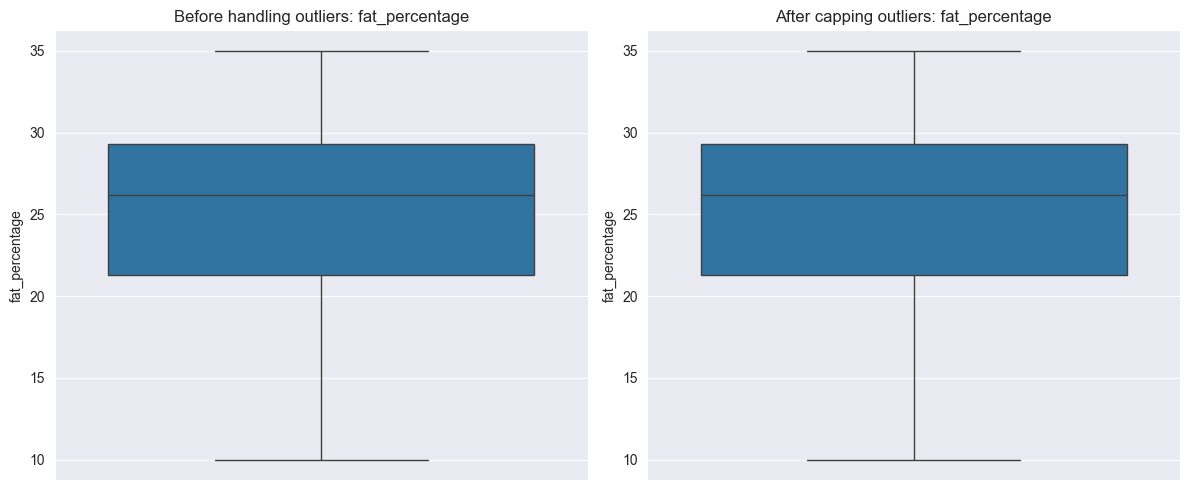

In [9]:
df_no_outliers = df.copy()

for var in continuous_vars:
    outliers, lower_bound, upper_bound = detect_outliers(df_no_outliers, var)
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df_no_outliers)) * 100

    print(f"\nOutliers in {var}:")
    print(f"Count: {outlier_count} ({outlier_percent:.2f}%)")
    print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

    # Visualize before capping
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(y=df_no_outliers[var])
    plt.title(f'Before handling outliers: {var}')

    # Cap outliers instead of removing them
    df_no_outliers[var] = df_no_outliers[var].clip(lower=lower_bound, upper=upper_bound)

    # Visualize after capping
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_no_outliers[var])
    plt.title(f'After capping outliers: {var}')

    plt.tight_layout()
    plt.show()

### Task 3

### Task 4

### Task 5

### Task 6